In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.4.3
pandas: 3.0.1


/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:17

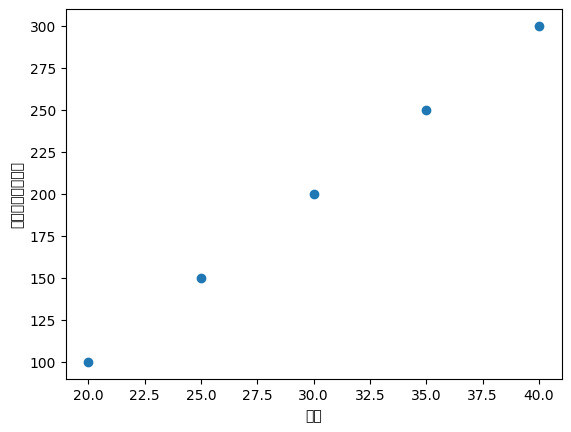

In [3]:
#　気温からアイスの売り上げを予測する
temper = np.array([20, 25, 30, 35, 40])
sales = np.array([100, 150, 200, 250, 300])

plt.scatter(temper, sales)
plt.xlabel("気温")
plt.ylabel("アイスの売り上げ")
plt.show()

In [4]:
#scikit-learnで直線を当てはめる
model = LinearRegression()
model.fit(temper.reshape(-1, 1), sales)

print("傾き:", model.coef_[0])
print("切片:", model.intercept_)

傾き: 9.999999999999998
切片: -99.99999999999994


In [5]:
prediction = model.predict(temper.reshape(-1, 1))

for i in range(len(temper)):
    diff = sales[i] - prediction[i]
    print(f"気温{temper[i]}度 → 実際: {sales[i]} 予測:{prediction[i]} ずれ:{diff:.1f}")

気温20度 → 実際: 100 予測:100.00000000000003 ずれ:-0.0
気温25度 → 実際: 150 予測:150.0 ずれ:0.0
気温30度 → 実際: 200 予測:200.0 ずれ:0.0
気温35度 → 実際: 250 予測:250.0 ずれ:0.0
気温40度 → 実際: 300 予測:300.0 ずれ:0.0


/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/qqqlq-desk/projects/nlp/.venv/lib/python3.12/site-packages/IPython/cor

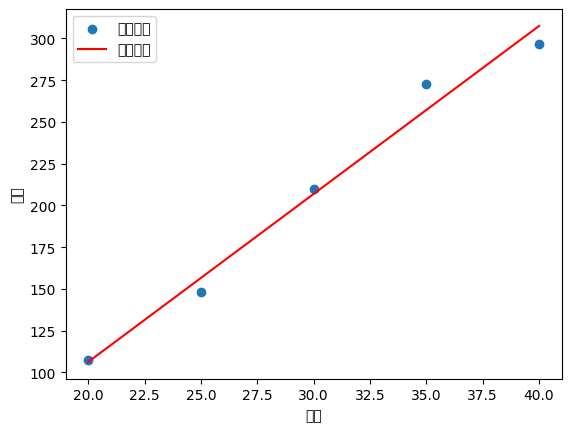

傾き: 10.059867730633021
切片: -94.91098730411437


In [6]:
# 現実っぽいデータ（ノイズ入り）
np.random.seed(42)
temper2 = np.array([20, 25, 30, 35, 40])
sales2 = np.array([100, 150, 200, 250, 300]) + np.random.normal(0, 15, 5)

model2 = LinearRegression()
model2.fit(temper2.reshape(-1, 1), sales2)

plt.scatter(temper2, sales2, label="実データ")
plt.plot(temper2, model2.predict(temper2.reshape(-1, 1)), color="red", label="回帰直線")
plt.xlabel("気温")
plt.ylabel("売上")
plt.legend()
plt.show()

print("傾き:", model2.coef_[0])
print("切片:", model2.intercept_)

In [7]:
model = LinearRegression()

#fit前は中身が空
print(type(model)) #クラスの種類を確認

model.fit(temper.reshape(-1, 1), sales)

#fit後に中身が入る
print("傾き:", model.coef_)
print("切片:", model.intercept_)

<class 'sklearn.linear_model._base.LinearRegression'>
傾き: [10.]
切片: -99.99999999999994


In [8]:
temper3 = np.array([20, 25, 30, 35, 40])
humi = np.array([40, 50, 60, 70, 80])
sales3 = np.array([100, 160, 210, 270, 310]) + np.random.normal(0, 10, 5)

X = np.column_stack([temper3, humi])
print("Xの形:", X.shape)
print(X)

Xの形: (5, 2)
[[20 40]
 [25 50]
 [30 60]
 [35 70]
 [40 80]]


In [9]:
model3 = LinearRegression()
model3.fit(X, sales3)

print("傾き:", model3.coef_)
print("切片:", model3.intercept_)

傾き: [2.10018827 4.20037654]
切片: -100.65704830704345


In [10]:
print("気温の範囲:",  temper3.min(), "~", temper3.max())
print("湿度の範囲:", humi.min(), "~", humi.max())

気温の範囲: 20 ~ 40
湿度の範囲: 40 ~ 80


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("標準化前:\n", X)
print("\n標準化後:\n", X_scaled.round(2))

model4 = LinearRegression()
model4.fit(X_scaled, sales3)
print("\n標準化後の傾き:", model4.coef_)

標準化前:
 [[20 40]
 [25 50]
 [30 60]
 [35 70]
 [40 80]]

標準化後:
 [[-1.41 -1.41]
 [-0.71 -0.71]
 [ 0.    0.  ]
 [ 0.71  0.71]
 [ 1.41  1.41]]

標準化後の傾き: [37.12643422 37.12643422]


In [12]:
# 気温と湿度が完全に連動しているケース（今回のデータ）
# 売上 = 2×気温 + 4×湿度 - 100 が「本当の式」だとする

# でもモデルから見るとこの2つは区別できない
# 売上 = 2×気温 + 4×湿度 - 100
# 売上 = 4×気温 + 2×湿度 - 100  ← これでも同じ予測値になってしまう
# 売上 = 6×気温 + 0×湿度 - 100  ← これも！

# 試してみる
X_temp_only = temper3.reshape(-1, 1) * 2  # 湿度 = 気温 × 2 なので

a_list = [0, 2, 4, 6]  # 気温の傾きをいろいろ変える

for a in a_list:
    b = (6 - a)  # 気温+湿度の傾きの合計を6に固定
    予測 = a * temper3 + b * humi - 100
    print(f"気温の傾き={a}, 湿度の傾き={b} → 予測値: {予測}")

気温の傾き=0, 湿度の傾き=6 → 予測値: [140 200 260 320 380]
気温の傾き=2, 湿度の傾き=4 → 予測値: [100 150 200 250 300]
気温の傾き=4, 湿度の傾き=2 → 予測値: [ 60 100 140 180 220]
気温の傾き=6, 湿度の傾き=0 → 予測値: [ 20  50  80 110 140]


In [ ]:
# データを少し変えるだけで傾きが激変するか確認する
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(0)
気温4 = np.array([20, 25, 30, 35, 40], dtype=float)
湿度4 = 気温4 * 2  # 完全に連動

売上4a = np.array([100, 160, 210, 270, 310])
売上4b = 売上4a.copy()
売上4b[2] += 5  # 1個だけちょっと変える

X4 = np.column_stack([気温4, 湿度4])

model_a = LinearRegression().fit(X4, 売上4a)
model_b = LinearRegression().fit(X4, 売上4b)

print("データa 傾き:", model_a.coef_.round(2))
print("データb 傾き:", model_b.coef_.round(2))
print()
print("売上の差はたった5なのに傾きはどれだけ変わった？")

データa 傾き: [5.3 5.3]
データb 傾き: [5.3 5.3]

売上の差はたった5なのに傾きはどれだけ変わった？


In [15]:
# 湿度を気温の完全なコピーにする
気温5 = np.array([20, 25, 30, 35, 40], dtype=float)
湿度5 = 気温5.copy()  # 完全に同じ値

売上5a = np.array([100, 160, 210, 270, 310], dtype=float)
売上5b = 売上5a.copy()
売上5b[2] += 5

X5 = np.column_stack([気温5, 湿度5])

model_5a = LinearRegression().fit(X5, 売上5a)
model_5b = LinearRegression().fit(X5, 売上5b)

print("データa 傾き:", model_5a.coef_.round(2))
print("データb 傾き:", model_5b.coef_.round(2))

データa 傾き: [5.3 5.3]
データb 傾き: [5.3 5.3]


In [1]:
# 気温と湿度が完全に同じとき
# モデルから見るとこの2つは同じ情報
# なので気温の傾きと湿度の傾きを個別に解釈できない

# 例えばこの結果
# 気温の傾き: 5.3, 湿度の傾き: 5.3

# 「気温が1上がると売上が5.3増える」と言えるか？
# → 言えない。気温が1上がると湿度も1上がるので
#   どちらの影響か分離できない

In [2]:
# 正しい順番
model_correct = LinearRegression()
model_correct.fit(気温.reshape(-1, 1), 売上)
print("正しい傾き:", model_correct.coef_[0])

# 逆にした場合
model_wrong = LinearRegression()
model_wrong.fit(売上.reshape(-1, 1), 気温)
print("逆にした傾き:", model_wrong.coef_[0])

NameError: name 'LinearRegression' is not defined

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression

気温 = np.array([20, 25, 30, 35, 40])
売上 = np.array([100, 150, 200, 250, 300])

# 正しい順番
model_correct = LinearRegression()
model_correct.fit(気温.reshape(-1, 1), 売上)
print("正しい傾き:", model_correct.coef_[0])

# 逆にした場合
model_wrong = LinearRegression()
model_wrong.fit(売上.reshape(-1, 1), 気温)
print("逆にした傾き:", model_wrong.coef_[0])

正しい傾き: 9.999999999999998
逆にした傾き: 0.09999999999999995
